In [99]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def rileva_oggetto(img_scena, img_template, soglia_match=12, resize_factor=2):
    """
    Rileva un template in un'immagine usando ORB, resize del template e Ratio Test.

    Parametri:
    - img_scena: l'immagine grande dove cercare.
    - img_template: il piccolo disegno da trovare.
    - soglia_match: numero minimo di match validi per confermare la presenza.
    - resize_factor: fattore di ingrandimento del template.

    Ritorna:
    - trovato (bool): True se l'oggetto è rilevato.
    - n_matches (int): Numero di match validi trovati.
    - visual_img (np.array): Immagine con i match disegnati.
    """

    # Resize del template per migliorare il rilevamento su oggetti piccoli
    template_resized = cv2.resize(
        img_template, None,
        fx=resize_factor, fy=resize_factor,
        interpolation=cv2.INTER_CUBIC
    )

    # Inizializzazione ORB ottimizzata
    orb = cv2.ORB_create(
        nfeatures=6000,     # Più feature per catturare piccoli dettagli
        scaleFactor=1.2,    # Piramide di scala più densa
        nlevels=18,
        edgeThreshold=15
    )

    # Trova keypoints e descrittori
    kp1, des1 = orb.detectAndCompute(template_resized, None)
    kp2, des2 = orb.detectAndCompute(img_scena, None)

    # Se non trova descrittori in una delle due immagini, esce subito
    if des1 is None or des2 is None:
        return False, 0, img_scena

    # Matching con Brute-Force e Ratio Test di Lowe
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    # Risultato e Immagine di output
    trovato = len(good_matches) >= soglia_match

    visual_img = cv2.drawMatches(
        template_resized, kp1,
        img_scena, kp2,
        good_matches[:40], # Mostra i migliori 40 per chiarezza
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return trovato, len(good_matches), visual_img

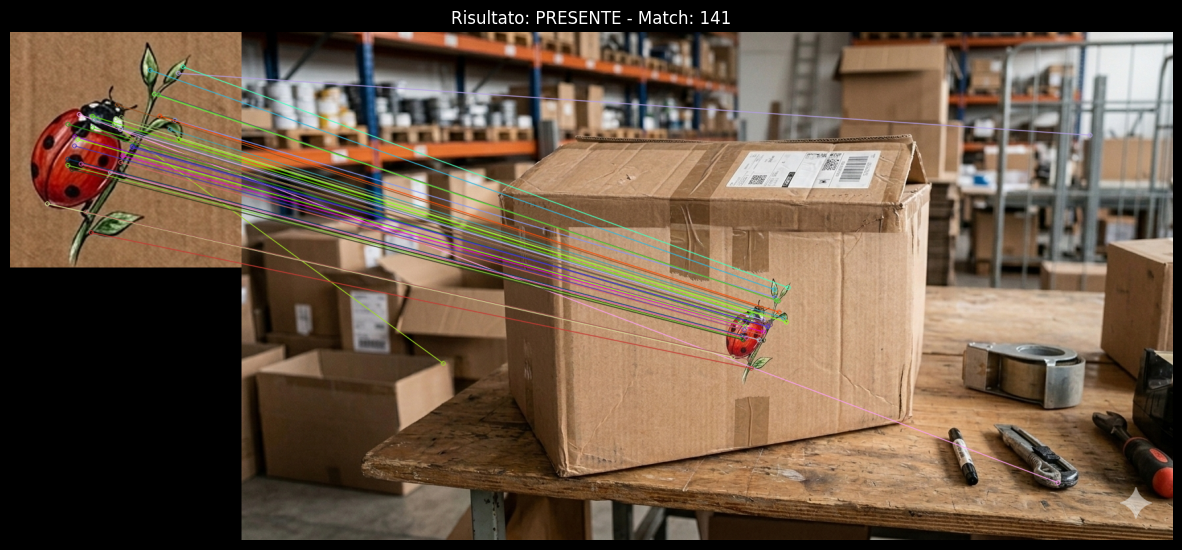

In [103]:
# --- ESEMPIO DI UTILIZZO ---

img_box = cv2.imread("img/scatola_con_coccinella_prospettiva.png")
img_target = cv2.imread("img/coccinella.png")

# Richiamo la funzione
esito, conteggio, img_risultato = rileva_oggetto(img_box, img_target)

# --- CORREZIONE COLORE ---
# Convertiamo il risultato da BGR a RGB per Matplotlib
img_corretta = cv2.cvtColor(img_risultato, cv2.COLOR_BGR2RGB)
print(f"Oggetto trovato: {esito} ({conteggio} match)")

plt.figure(figsize=(15, 8))
plt.title(f"Risultato: {'PRESENTE' if esito else 'ASSENTE'} - Match: {conteggio}")
plt.imshow(img_corretta)
plt.axis("off")
plt.show()

In [78]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def rileva_oggetto_rotazione(img_scena, img_template, soglia_match=12, resize_factor=2):
    # Resize iniziale del template
    template_base = cv2.resize(
        img_template, None,
        fx=resize_factor, fy=resize_factor,
        interpolation=cv2.INTER_CUBIC
    )

    orb = cv2.ORB_create(nfeatures=6000, scaleFactor=1.2, nlevels=12, edgeThreshold=15)
    kp2, des2 = orb.detectAndCompute(img_scena, None)

    if des2 is None: return False, 0, img_scena

    best_matches = []
    best_kp1 = None
    best_template = None

    # --- CICLO DI ROTAZIONE OGNI 5 GRADI ---
    h, w = template_base.shape[:2]
    centro = (w // 2, h // 2)

    for angolo in range(0, 360, 5):
        # Ruota il template
        matrice = cv2.getRotationMatrix2D(centro, angolo, 1.0)
        template_ruotato = cv2.warpAffine(template_base, matrice, (w, h))

        # Trova feature sul template ruotato
        kp1, des1 = orb.detectAndCompute(template_ruotato, None)
        if des1 is None: continue

        # Matching
        bf = cv2.BFMatcher(cv2.NORM_HAMMING)
        matches = bf.knnMatch(des1, des2, k=2)

        current_good = [m for m, n in matches if m.distance < 0.75 * n.distance]

        # Se questa rotazione è la migliore trovata finora, salvala
        if len(current_good) > len(best_matches):
            best_matches = current_good
            best_kp1 = kp1
            best_template = template_ruotato

    # --- FINE CICLO ---

    if best_template is None:
        return False, 0, img_scena

    trovato = len(best_matches) >= soglia_match

    visual_img = cv2.drawMatches(
        best_template, best_kp1,
        img_scena, kp2,
        best_matches[:40],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return trovato, len(best_matches), visual_img

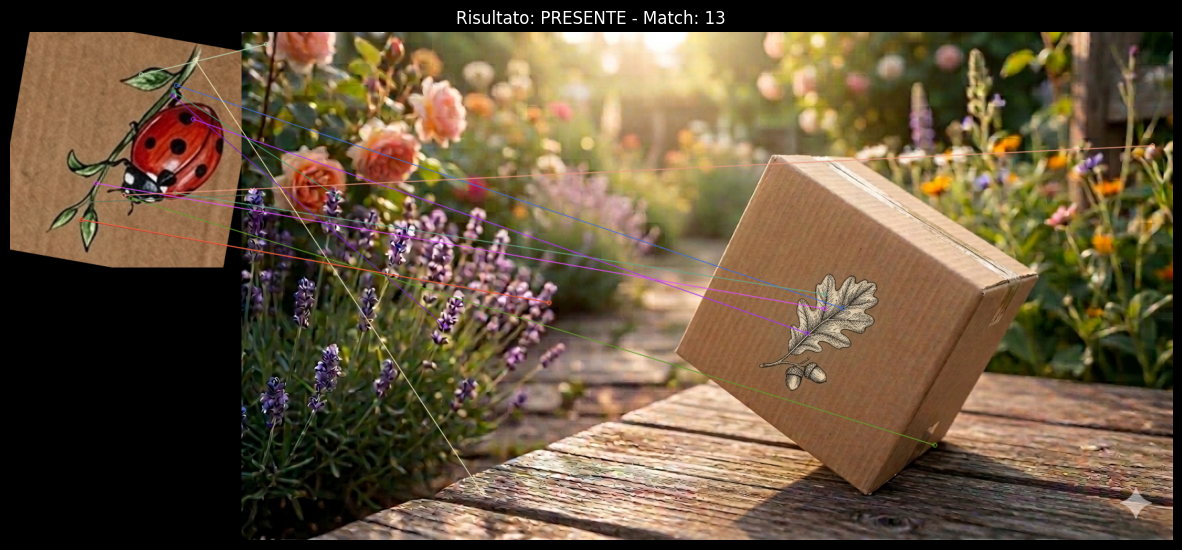

In [83]:
# --- ESEMPIO DI UTILIZZO ---

img_box = cv2.imread("img/scatola_con_altro_disegno.png")
img_target = cv2.imread("img/coccinella.png")

# Richiamo la funzione
esito, conteggio, img_risultato = rileva_oggetto_rotazione(img_box, img_target)

# --- CORREZIONE COLORE ---
# Convertiamo il risultato da BGR a RGB per Matplotlib
img_corretta = cv2.cvtColor(img_risultato, cv2.COLOR_BGR2RGB)
print(f"Oggetto trovato: {esito} ({conteggio} match)")

plt.figure(figsize=(15, 8))
plt.title(f"Risultato: {'PRESENTE' if esito else 'ASSENTE'} - Match: {conteggio}")
plt.imshow(img_corretta)
plt.axis("off")
plt.show()